In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

In [3]:
X_train = pd.read_csv('preprocessed/X_train_scaled.csv')
X_test = pd.read_csv('preprocessed/X_test_scaled.csv')
y_train = pd.read_csv('preprocessed/y_train.csv').iloc[:, 0]
y_test = pd.read_csv('preprocessed/y_test.csv').iloc[:, 0]

In [ ]:
# This implements the Newton-based approach (similar to the paper) and addresses class imbalances
lr_model = LogisticRegression(
    solver='newton-cg',   
    class_weight='balanced', 
    max_iter=100,         
    verbose=1           
)

lr_model.fit(X_train, y_train)

Newton-CG iter = 0
  Check Convergence
    max |gradient| <= tol: 0.07707478478068343 <= 0.0001 False
Newton-CG iter = 1
  Check Convergence
    max |gradient| <= tol: 0.014873540113185478 <= 0.0001 False
Newton-CG iter = 2
  Check Convergence
    max |gradient| <= tol: 0.012577907612789629 <= 0.0001 False
Newton-CG iter = 3
  Check Convergence
    max |gradient| <= tol: 0.002572681499057936 <= 0.0001 False
Newton-CG iter = 4
  Check Convergence
    max |gradient| <= tol: 0.0011060661800656093 <= 0.0001 False
Newton-CG iter = 5
  Check Convergence
    max |gradient| <= tol: 0.00021512754289251118 <= 0.0001 False
Newton-CG iter = 6
  Check Convergence
    max |gradient| <= tol: 3.122903868112276e-05 <= 0.0001 True
  Solver did converge at loss = 0.5865578800503843.


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

## Results of Newton's Method
It seems that Newton's method converges very close to expecations: in the paper, it converged at 5 iterations, and for us it was at 6. The gradient has reached a very low value at the 6th iteration, and the converged loss was 0.5866. Whether this is a good or bad loss will depend on the overall evaluation with the other models.

In [5]:
# Probability scores for the test set
y_prob = lr_model.predict_proba(X_test)[:, 1]

# Test different thresholds
thresholds = [0.3, 0.4, 0.5, 0.6]

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    print(f"--- Threshold: {t} ---")
    print(classification_report(y_test, y_pred_t))

--- Threshold: 0.3 ---
              precision    recall  f1-score   support

           0       0.25      0.29      0.27     72678
           1       0.89      0.87      0.88    493932

    accuracy                           0.80    566610
   macro avg       0.57      0.58      0.58    566610
weighted avg       0.81      0.80      0.80    566610

--- Threshold: 0.4 ---
              precision    recall  f1-score   support

           0       0.23      0.45      0.30     72678
           1       0.91      0.77      0.83    493932

    accuracy                           0.73    566610
   macro avg       0.57      0.61      0.57    566610
weighted avg       0.82      0.73      0.77    566610

--- Threshold: 0.5 ---
              precision    recall  f1-score   support

           0       0.21      0.63      0.31     72678
           1       0.92      0.64      0.76    493932

    accuracy                           0.64    566610
   macro avg       0.56      0.64      0.53    566610
weigh

## Evaluating Threshold Results
We can see that as the probability threshold increases, then for non-defaulters (1), the Precision increases and Recall falls sharply. This is because the model is very conservative with whom it considers a non-defaulter. On the other hand, recall for defaulters (0) sharply moves upwards with the more conservative models.

## Checking feature importance through ablation analysis

In [ ]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr_model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print(feature_importance.head(10))

                       Feature  Coefficient
53              total_bc_limit     3.996128
45          num_tl_90g_dpd_24m     1.894668
54  total_il_high_credit_limit     1.741458
51             tot_hi_cred_lim     1.497507
31                    mort_acc     1.094652
35             num_actv_rev_tl     1.072439
5                      issue_d     0.877694
28        mo_sin_old_rev_tl_op     0.678206
13                   revol_bal     0.633575
8             earliest_cr_line     0.604793


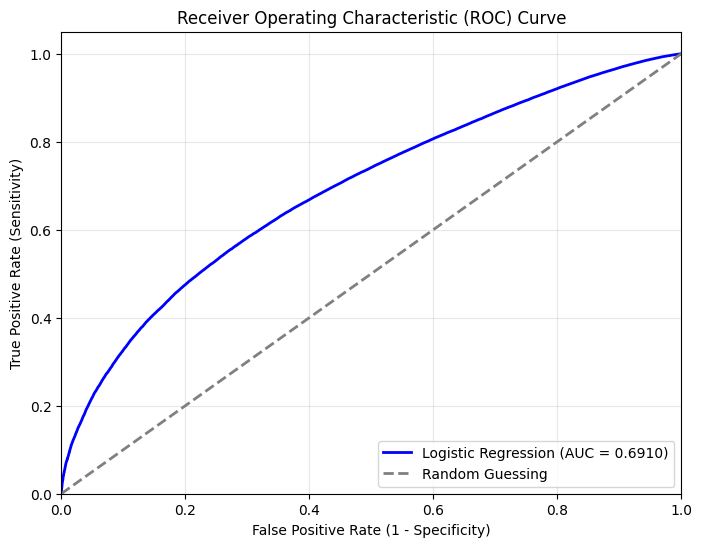

Final Logistic Regression AUC: 0.6910


In [ ]:
# Calculate the ROC curve points
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
lr_auc = roc_auc_score(y_test, y_prob)

# Create the plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'Logistic Regression (AUC = {lr_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Guessing')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"Final Logistic Regression AUC: {lr_auc:.4f}")

=== Standard Metrics (at 0.5 threshold) ===
Accuracy:  0.6417
Precision: 0.9223
Recall:    0.6432
F1-score:  0.7578
AUC-ROC:   0.6910


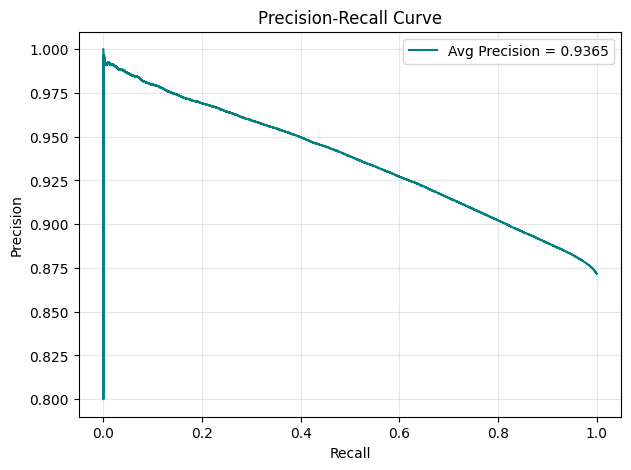

In [ ]:
# We again calculate the metrics for final comparison with plotting
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    roc_auc_score, 
    precision_recall_curve, 
    average_precision_score,
    roc_curve
)
import matplotlib.pyplot as plt

# Use predict() for hard labels (0/1) and predict_proba() for probability scores
y_pred = lr_model.predict(X_test)
y_prob = lr_model.predict_proba(X_test)[:, 1]

# Calculate Standard Metrics
print("=== Standard Metrics (at 0.5 threshold) ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_prob):.4f}")

# Precision-Recall Behavior
precision, recall, _ = precision_recall_curve(y_test, y_prob)
avg_precision = average_precision_score(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision, label=f'Avg Precision = {avg_precision:.4f}', color='teal')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.show()